# Graph Signal Processing of Brain Connectivity Data
This notebook implements the workflow for analyzing structural and functional brain networks using graph signal processing.

In [47]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [51]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from numpy.linalg import norm, eig
from scipy.stats import zscore

# Set data path
mypath = '/content/drive/MyDrive/ColabNotebooks/OHBM2025/sample_data_GSP/'  # Change to your actual path


# Load structural connectome and functional timecourses
A = scipy.io.loadmat(mypath + 'SC.mat')['SC']
X = scipy.io.loadmat(mypath + 'RS_TCS.mat')['X_RS']


Text(0, 0.5, 'regions')

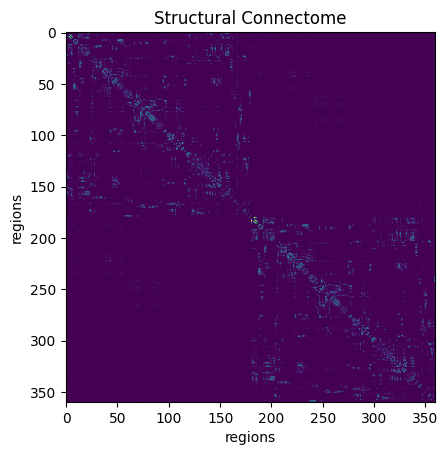

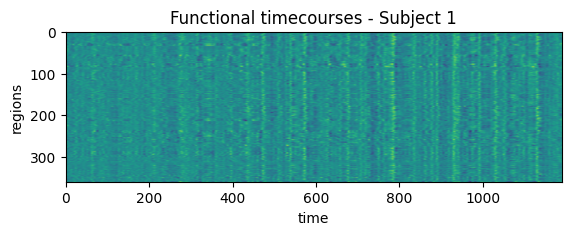

In [33]:
# Visualize data
plt.figure(); plt.imshow(np.log1p(A)); plt.title('Structural Connectome'); plt.xlabel('regions'); plt.ylabel('regions')
plt.figure(); plt.imshow(X[:, :, 0]); plt.title('Functional timecourses - Subject 1'); plt.xlabel('time'); plt.ylabel('regions')


Text(0, 0.5, 'regions')

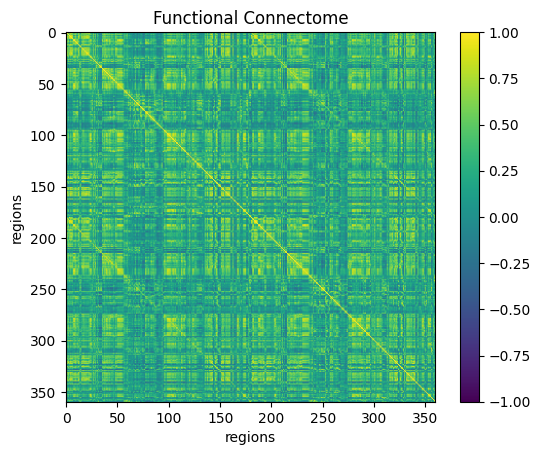

In [34]:
# Compute functional connectivity
FC = np.corrcoef(X[:, :, 0])
plt.figure(); plt.imshow(FC, vmin=-1, vmax=1); plt.colorbar(); plt.title('Functional Connectome'); plt.xlabel('regions'); plt.ylabel('regions')


Text(0, 0.5, 'regions')

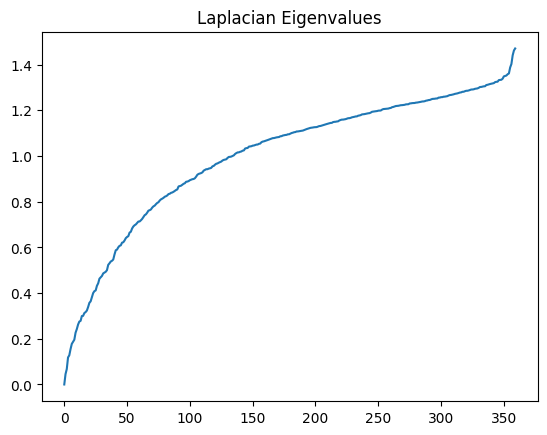

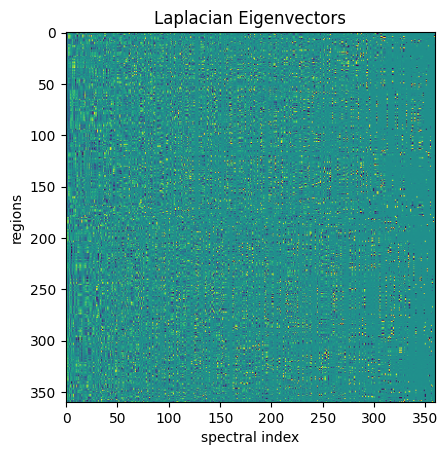

In [35]:
# Normalize adjacency matrix
D = np.diag(np.sum(A, axis=1))
D_inv_sqrt = np.diag(1.0 / np.sqrt(np.sum(A, axis=1)))
Anorm = D_inv_sqrt @ A @ D_inv_sqrt

# Laplacian
Lnorm = np.eye(A.shape[0]) - Anorm
LambdaL, U = eig(Lnorm)
LambdaL = np.real(LambdaL)
U = np.real(U)

# Sort eigenvalues and eigenvectors
idx = np.argsort(LambdaL)
LambdaL = LambdaL[idx]
U = U[:, idx]

plt.figure(); plt.plot(LambdaL); plt.title('Laplacian Eigenvalues')
plt.figure(); plt.imshow(U, vmin=-0.2, vmax=0.2); plt.title('Laplacian Eigenvectors'); plt.xlabel('spectral index'); plt.ylabel('regions')


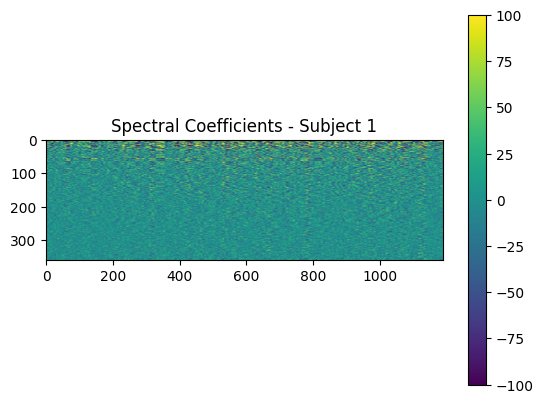

In [36]:
# Graph Fourier Transform
nsubjs = X.shape[2]
X_hat = np.array([U.T @ X[:, :, s] for s in range(nsubjs)]).transpose(1, 2, 0)

plt.figure(); plt.imshow(X_hat[:, :, 0], vmin=-100, vmax=100); plt.title('Spectral Coefficients - Subject 1'); plt.colorbar()


In [41]:
# Compute Power Spectral Density
pow = np.abs(X_hat)**2
PSD = np.mean(pow, axis=1)

mPSD = np.mean(PSD, axis=1)
AUCTOT = np.trapezoid(mPSD)
AUC, n = 0, 0
while AUC < AUCTOT / 2 and n < len(mPSD):
    AUC = np.trapezoid(mPSD[:n+1])
    n += 1
NN = max(n-2, 1)


Text(0.5, 1.0, 'High-Frequency Harmonics')

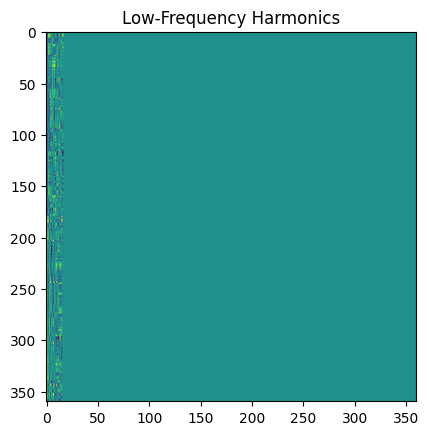

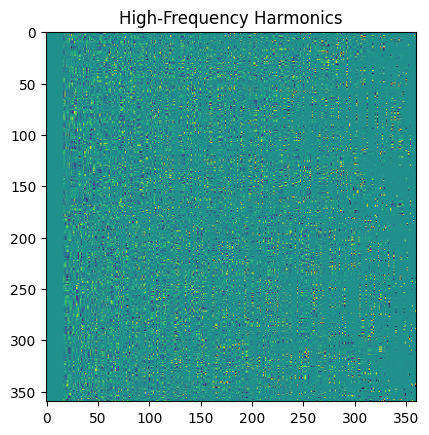

In [43]:
# Low- and high-frequency eigenvectors
Ulow = np.zeros_like(U)
Uhigh = np.zeros_like(U)
Ulow[:, :NN] = U[:, :NN]
Uhigh[:, NN:] = U[:, NN:]

plt.figure(); plt.imshow(Ulow, vmin=-0.2, vmax=0.2); plt.title('Low-Frequency Harmonics')
plt.figure(); plt.imshow(Uhigh, vmin=-0.2, vmax=0.2); plt.title('High-Frequency Harmonics')


Text(0.5, 1.0, 'Decoupled Signals - Subject 1')

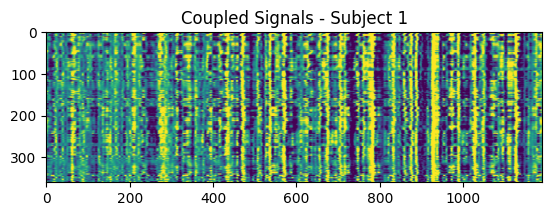

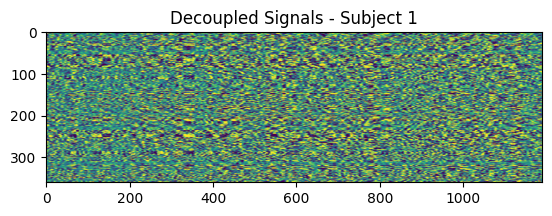

In [44]:
# Reconstruct signals
X_c = np.array([Ulow @ X_hat[:, :, s] for s in range(nsubjs)]).transpose(1, 2, 0)
X_d = np.array([Uhigh @ X_hat[:, :, s] for s in range(nsubjs)]).transpose(1, 2, 0)

plt.figure(); plt.imshow(X_c[:, :, 0], vmin=-30, vmax=30); plt.title('Coupled Signals - Subject 1')
plt.figure(); plt.imshow(X_d[:, :, 0], vmin=-30, vmax=30); plt.title('Decoupled Signals - Subject 1')


Text(0.5, 0, 'regions')

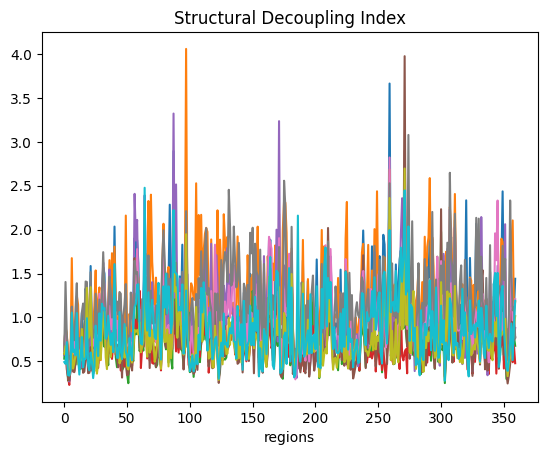

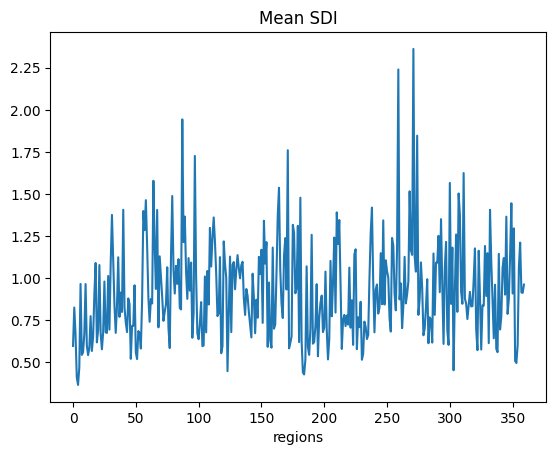

In [45]:
# Norms and Structural Decoupling Index (SDI)
N_c = np.linalg.norm(X_c, axis=1)
N_d = np.linalg.norm(X_d, axis=1)
SDI = N_d / (N_c + 1e-8)
meanSDI = np.mean(SDI, axis=1)

plt.figure(); plt.plot(SDI); plt.title('Structural Decoupling Index'); plt.xlabel('regions')
plt.figure(); plt.plot(meanSDI); plt.title('Mean SDI'); plt.xlabel('regions')


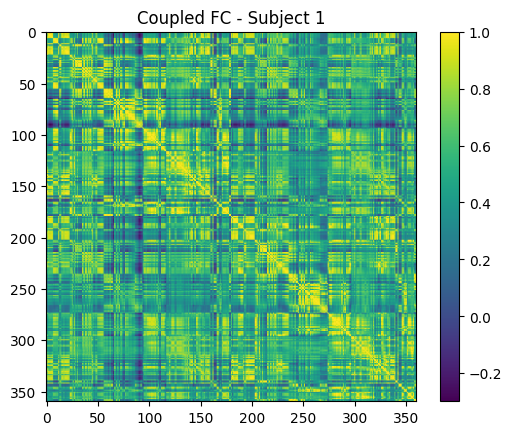

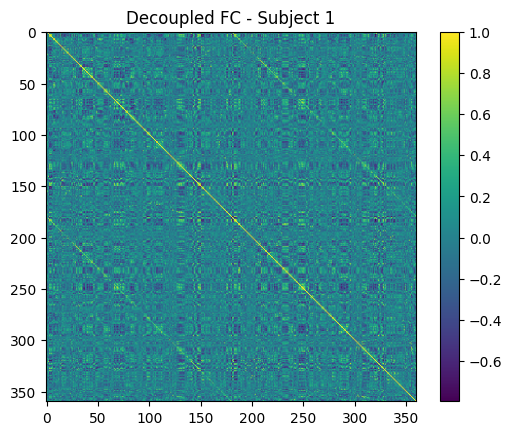

In [46]:
# Compute coupled and decoupled FC
FC_c = np.array([np.corrcoef(X_c[:, :, s]) for s in range(nsubjs)])
FC_d = np.array([np.corrcoef(X_d[:, :, s]) for s in range(nsubjs)])

plt.figure(); plt.imshow(FC_c[0]); plt.title('Coupled FC - Subject 1'); plt.colorbar()
plt.figure(); plt.imshow(FC_d[0]); plt.title('Decoupled FC - Subject 1'); plt.colorbar()
